<a href="https://colab.research.google.com/github/simranchoudhary2907/Activity/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed
np.random.seed(42)

# Generate synthetic data
X = np.linspace(0, 10, 100)
true_slope = 2.5
true_intercept = 5.0
noise = np.random.normal(0, 1, 100)

y = true_slope * X + true_intercept + noise

# Save to CSV
df = pd.DataFrame({"X": X, "y": y})
df.to_csv("synthetic_data.csv", index=False)

print("Dataset created and saved as synthetic_data.csv")


Dataset created and saved as synthetic_data.csv


In [55]:
data = pd.read_csv("synthetic_data.csv")
X = data["X"].values
y = data["y"].values

n = len(X)


In [56]:
X_b = np.c_[np.ones(n), X]   # [1  X]


In [57]:
theta = np.zeros(2)   # [theta0, theta1]
learning_rate = 0.01
iterations = 1000

In [58]:
mse_history = []

for i in range(iterations):
    predictions = X_b.dot(theta)
    errors = predictions - y

    gradients = (1/n) * X_b.T.dot(errors)

    theta = theta - learning_rate * gradients

    mse = (1/(2*n)) * np.sum(errors**2)
    mse_history.append(mse)

print("Final Theta values:")
print("Theta0 (Intercept):", theta[0])
print("Theta1 (Slope):", theta[1])

Final Theta values:
Theta0 (Intercept): 4.464677914889677
Theta1 (Slope): 2.5683002216296518


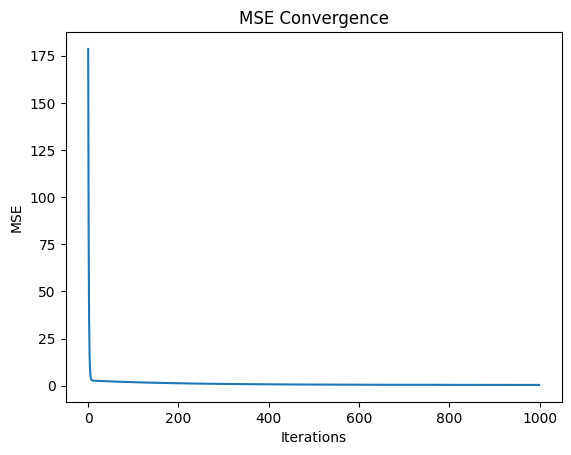

In [59]:
plt.figure()
plt.plot(mse_history)
plt.title("MSE Convergence")
plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.show()

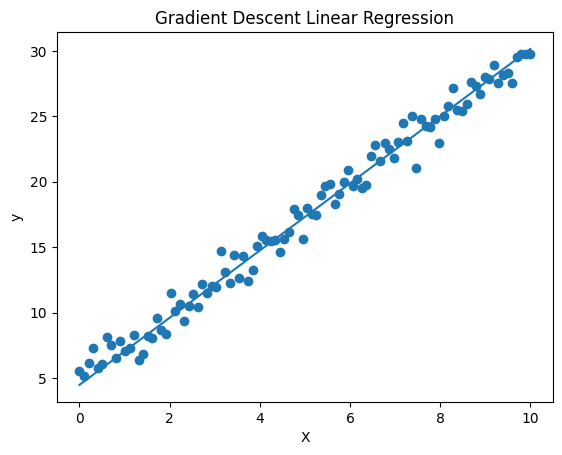

In [50]:
plt.figure()
plt.scatter(X, y)
plt.plot(X, X_b.dot(theta))
plt.title("Gradient Descent Linear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [51]:
import pandas as pd

data = pd.read_csv("/advertising.csv")
print(data.head())
print(data.isnull().sum())
print(data.describe())


      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


In [52]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

X = data[["TV"]]
y = data["Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_slr = LinearRegression()
model_slr.fit(X_train, y_train)

y_pred = model_slr.predict(X_test)

print("Intercept:", model_slr.intercept_)
print("Slope:", model_slr.coef_)
print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


Intercept: 7.007108428241848
Slope: [0.05548294]
R2: 0.802561303423698
MSE: 6.101072906773963


In [53]:
X_multi = data[["TV", "Radio", "Newspaper"]]

X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)

model_mlr = LinearRegression()
model_mlr.fit(X_train, y_train)

y_pred_multi = model_mlr.predict(X_test)

print("Coefficients:", model_mlr.coef_)
print("Intercept:", model_mlr.intercept_)
print("R2:", r2_score(y_test, y_pred_multi))
print("MSE:", mean_squared_error(y_test, y_pred_multi))


Coefficients: [0.05450927 0.10094536 0.00433665]
Intercept: 4.714126402214127
R2: 0.9059011844150826
MSE: 2.9077569102710896


In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

X_vif = data[["TV", "Radio", "Newspaper"]].values

vif_data = pd.DataFrame()
vif_data["Feature"] = ["TV", "Radio", "Newspaper"]
vif_data["VIF"] = [variance_inflation_factor(X_vif, i) for i in range(X_vif.shape[1])]

print(vif_data)


     Feature       VIF
0         TV  2.486772
1      Radio  3.285462
2  Newspaper  3.055245


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("/Car_Price.csv")   # change path if needed

# Remove extra spaces from column names
data.columns = data.columns.str.strip()

print(data.head())


     Brand                     Model  Year  Selling_Price  KM_Driven    Fuel  \
0   Maruti             Maruti 800 AC  2007          60000      70000  Petrol   
1   Maruti  Maruti Wagon R LXI Minor  2007         135000      50000  Petrol   
2  Hyundai      Hyundai Verna 1.6 SX  2012         600000     100000  Diesel   
3   Datsun    Datsun RediGO T Option  2017         250000      46000  Petrol   
4    Honda     Honda Amaze VX i-DTEC  2014         450000     141000  Diesel   

  Seller_Type Transmission         Owner  
0  Individual       Manual   First Owner  
1  Individual       Manual   First Owner  
2  Individual       Manual   First Owner  
3  Individual       Manual   First Owner  
4  Individual       Manual  Second Owner  


In [33]:
from sklearn.model_selection import train_test_split

# Select required features
data = data[["Year", "KM_Driven", "Transmission", "Fuel", "Selling_Price"]]

# Separate features and target
X = data.drop("Selling_Price", axis=1)
y = data["Selling_Price"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])



Training samples: 3472
Testing samples: 868


In [34]:
# Encode categorical temporarily to calculate variance
X_encoded = pd.get_dummies(X, drop_first=True)

variances = X_encoded.var()

print("Feature Variances:\n", variances)
print("\nHighest Variance Feature:", variances.idxmax())
print("Lowest Variance Feature:", variances.idxmin())


Feature Variances:
 Year                   1.776912e+01
KM_Driven              2.175672e+09
Transmission_Manual    9.259157e-02
Fuel_Diesel            2.500423e-01
Fuel_Electric          2.304147e-04
Fuel_LPG               5.272669e-03
Fuel_Petrol            2.499403e-01
dtype: float64

Highest Variance Feature: KM_Driven
Lowest Variance Feature: Fuel_Electric


In [36]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns (important!)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)



In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [38]:
# Add intercept term
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

y_train = y_train.values.reshape(-1,1)
y_test = y_test.values.reshape(-1,1)


In [39]:
np.random.seed(42)

n_features = X_train.shape[1]
W = np.random.randn(n_features, 1)

learning_rate = 0.01
iterations = 1000

m = len(y_train)

loss_history = []


In [40]:
for i in range(iterations):

    # Predictions
    y_pred = X_train.dot(W)

    # Error
    error = y_pred - y_train

    # Cost (MSE)
    cost = (1/(2*m)) * np.sum(error**2)
    loss_history.append(cost)

    # Gradient
    gradients = (1/m) * X_train.T.dot(error)

    # Update weights
    W = W - learning_rate * gradients

print("Training Complete ✅")


Training Complete ✅


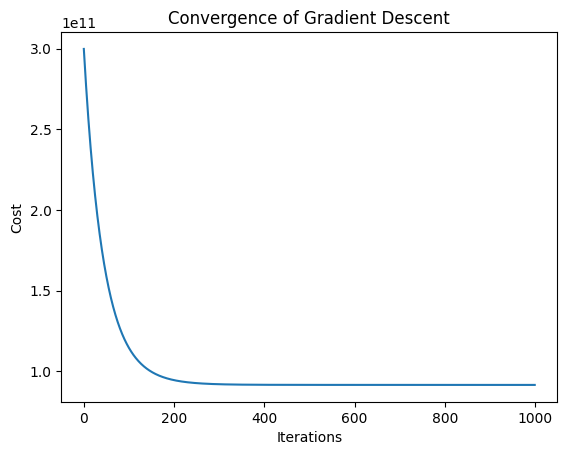

In [41]:
plt.figure()
plt.plot(loss_history)
plt.title("Convergence of Gradient Descent")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()


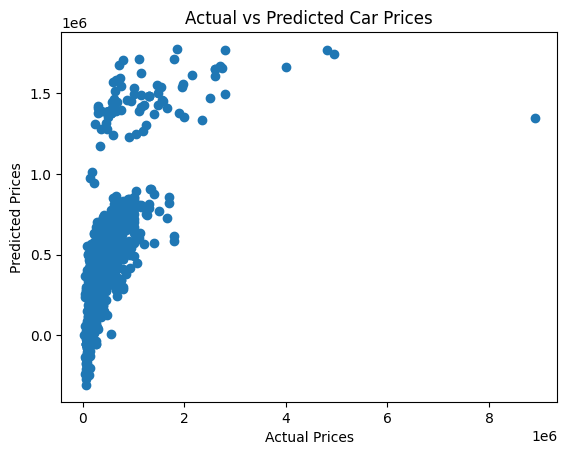

In [42]:
# Test Predictions
y_test_pred = X_test.dot(W)

plt.figure()
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Car Prices")
plt.show()


In [43]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)


Mean Squared Error: 184999402477.7711
R2 Score: 0.39378304207994597
